# Cost Matrix — Definition & Visualization

The cost matrix `C` of shape `(N, N)` is the backbone of the warehouse problem.  
`C[i, j]` = cost of shipping one unit from warehouse `i` to warehouse `j`.

**Properties enforced by the environment:**
- `C[i, i] = 0` — no cost to stay
- `C[i, j] = C[j, i]` — symmetric (same cost both ways)
- Values in `[0.5, 2.0]` when randomly generated

This notebook lets you:
1. Define a cost matrix manually or generate one randomly
2. Visualize it as a **heatmap**
3. Visualize it as a **warehouse network graph** (nodes = warehouses, edge thickness = cost)
4. Plug it back into the environment

In [1]:
%pwd
%cd C:\Users\pcc\Desktop\CS\3A\MVA\S2\RL\RL-project
%pwd

C:\Users\pcc\Desktop\CS\3A\MVA\S2\RL\RL-project


C:\Users\pcc\AppData\Roaming\Python\Python310\site-packages\IPython\core\magics\osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


'C:\\Users\\pcc\\Desktop\\CS\\3A\\MVA\\S2\\RL\\RL-project'

In [2]:
from env.warehouse_env import WarehouseEnv
import numpy as np
import matplotlib.pyplot as plt
import yaml
import os
def load_config(config_name: str) -> dict:
    base_path = os.path.join("configs", "default.yaml")
    cfg_path = os.path.join("configs", f"{config_name}.yaml")

    with open(base_path) as f:
        cfg = yaml.safe_load(f)

    if config_name != "default":
        with open(cfg_path) as f:
            override = yaml.safe_load(f)
        for key, val in override.items():
            if key == "_base_":
                continue
            if isinstance(val, dict) and key in cfg:
                cfg[key].update(val)
            else:
                cfg[key] = val
    return cfg

cfg = load_config("default")

env = WarehouseEnv(cfg, seed=42)
state = env.reset()
print("Initial state:", state)

## 1 episode of random actions of length 5
for _ in range(5):
    action = env.sample_action()  # Random action for testing
    s_, r, done, info = env.step(action)
    print(f"Action:\n{action}\nReward: {r}\nNext state: {s_}\nDone: {done}\n")


Initial state: {'inventory': array([380.56985 , 393.03217 ,  64.056816, 225.19296 ], dtype=float32), 'demand': array([ 9., 11.,  9., 10.], dtype=float32)}
Action:
[[  0.         54.77786   165.4517     29.65489  ]
 [  7.6729574   0.          2.6080396   2.8346043]
 [  1.4890403   5.680883    0.         10.479493 ]
 [ 15.131926   29.324404   40.801876    0.       ]]
Reward: -15.622686212364297
Next state: {'inventory': array([100., 100., 100., 100.], dtype=float32), 'demand': array([ 7.,  9., 12.,  9.], dtype=float32)}
Done: False

Action:
[[ 0.        15.127042  32.343452   1.9294671]
 [12.144845   0.         5.2044005  2.6231704]
 [ 6.9231625  2.4837246  0.        26.360676 ]
 [15.9718485  6.3367233  4.94767    0.       ]]
Reward: -0.011548595952750708
Next state: {'inventory': array([78.63989 , 94.97508 , 94.72796 , 94.657074], dtype=float32), 'demand': array([ 7., 14.,  4.,  8.], dtype=float32)}
Done: False

Action:
[[ 0.        10.743636  18.747406   4.1202106]
 [ 3.076741   0.    

In [3]:
import sys
sys.path.append('..')  # so we can import from the project root

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'monospace',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

WAREHOUSE_NAMES = [f'W{i}' for i in range(1, 17)]  # up to 16 warehouses
SEED = 42

---
## 1 — Define the Cost Matrix

Choose **one** of the three cells below. Comment out the others.

In [4]:
# ── OPTION A: Manual definition (small scenario, N=4) ──────────────────────
# Rows/cols: W1, W2, W3, W4
# Story: W1-W2 are close (cost 0.5), W3-W4 are far from everyone else (cost 1.8+)

C_manual = np.array([
    #  W1    W2    W3    W4
    [0.0,  0.5,  1.2,  1.8],  # from W1
    [0.5,  0.0,  1.5,  1.9],  # from W2
    [1.2,  1.5,  0.0,  0.7],  # from W3
    [1.8,  1.9,  0.7,  0.0],  # from W4
], dtype=np.float32)

N = 4
C = C_manual
labels = WAREHOUSE_NAMES[:N]
print(f'Cost matrix (N={N}):')
print(C)

Cost matrix (N=4):
[[0.  0.5 1.2 1.8]
 [0.5 0.  1.5 1.9]
 [1.2 1.5 0.  0.7]
 [1.8 1.9 0.7 0. ]]


In [5]:
# ── OPTION B: Random generation (mirrors the WarehouseEnv logic) ───────────
# Uncomment this cell to use it

# N = 9  # try 4, 9, or 16
# rng = np.random.default_rng(SEED)
# c = rng.uniform(0.5, 2.0, size=(N, N)).astype(np.float32)
# c = (c + c.T) / 2           # symmetrise
# np.fill_diagonal(c, 0.0)    # zero diagonal
# C = c
# labels = WAREHOUSE_NAMES[:N]
# print(f'Random cost matrix (N={N}, seed={SEED}):')
# print(C.round(2))

In [6]:
# ── OPTION C: Load from env (uses config) ─────────────────────────────────
# Uncomment to pull the exact matrix the env will use

# import yaml
# from env.warehouse_env import WarehouseEnv
# with open('../configs/small.yaml') as f:
#     cfg_override = yaml.safe_load(f)
# with open('../configs/default.yaml') as f:
#     cfg = yaml.safe_load(f)
# cfg['env'].update(cfg_override.get('env', {}))
# env = WarehouseEnv(cfg['env'], seed=SEED)
# C = env.cost_matrix
# N = env.n
# labels = WAREHOUSE_NAMES[:N]

---
## 2 — Heatmap

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/cost_matrix_heatmap.png'

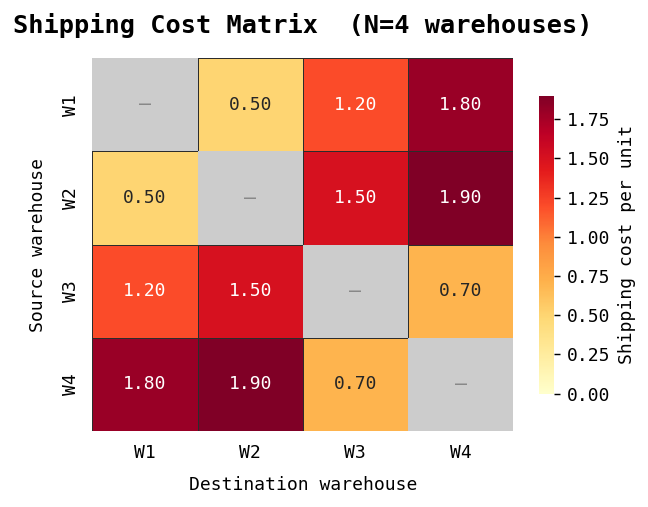

In [7]:
fig, ax = plt.subplots(figsize=(max(5, N * 0.9), max(4, N * 0.8)))

# Mask the diagonal (self-shipment = 0, not interesting)
mask = np.eye(N, dtype=bool)

sns.heatmap(
    C,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='#2c2c2c',
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'label': 'Shipping cost per unit', 'shrink': 0.8},
    ax=ax,
    vmin=0,
    vmax=C.max(),
)

# Draw diagonal as grey boxes
for i in range(N):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='#cccccc', lw=0))
    ax.text(i + 0.5, i + 0.5, '—', ha='center', va='center', fontsize=11, color='#888')

ax.set_title(f'Shipping Cost Matrix  (N={N} warehouses)', fontsize=14, pad=14, fontweight='bold')
ax.set_xlabel('Destination warehouse', labelpad=8)
ax.set_ylabel('Source warehouse', labelpad=8)
ax.tick_params(left=False, bottom=False)

plt.tight_layout()
plt.savefig('../outputs/cost_matrix_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved → outputs/cost_matrix_heatmap.png')

---
## 3 — Warehouse Network Graph

Each warehouse is a node. Each edge represents a shipping route.  
**Edge thickness and color** encode the shipping cost — thick dark red = expensive, thin light = cheap.

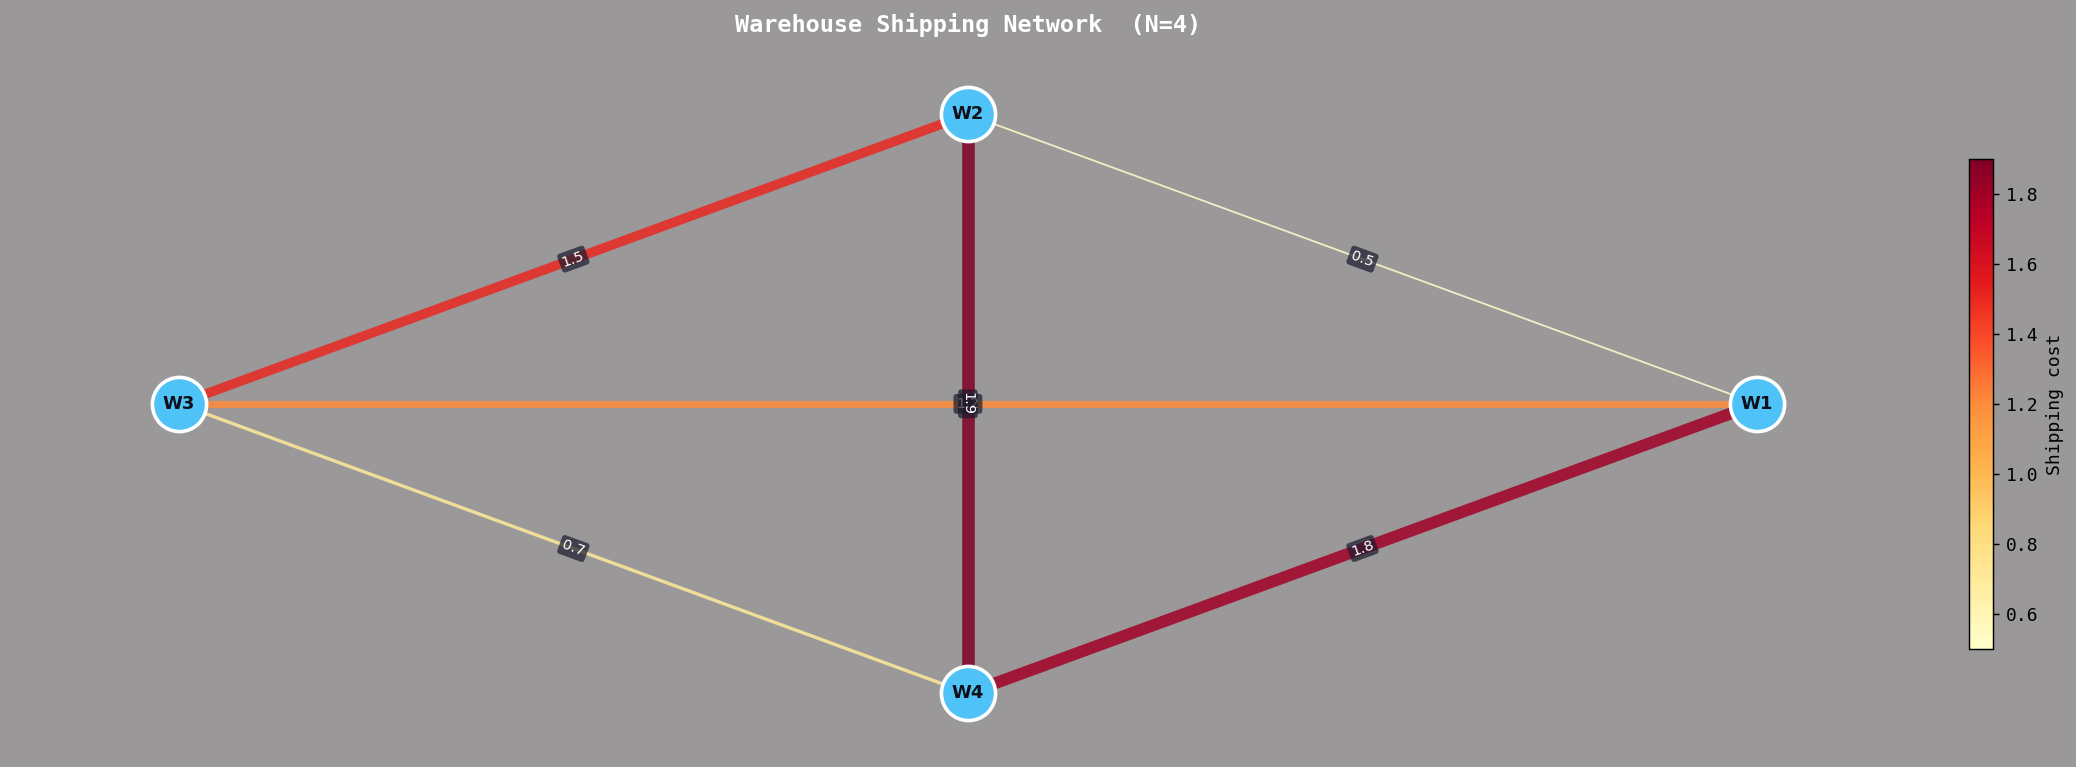

Saved : outputs/cost_matrix_network.png


In [ ]:
def draw_warehouse_network(C, labels, title='Warehouse Shipping Network', ax=None):
    N = len(labels)
    G = nx.Graph()
    G.add_nodes_from(range(N))

    edges, weights = [], []
    for i in range(N):
        for j in range(i + 1, N):
            G.add_edge(i, j, weight=C[i, j])
            edges.append((i, j))
            weights.append(C[i, j])

    # Layout: circular for small N, spring for larger
    pos = nx.circular_layout(G) if N <= 6 else nx.kamada_kawai_layout(G, weight='weight')

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    ax.set_facecolor('#0f0f1a')

    # Normalise weights for visual encoding
    w_arr = np.array(weights)
    w_norm = (w_arr - w_arr.min()) / (w_arr.max() - w_arr.min() + 1e-8)
    edge_widths = 1.0 + w_norm * 6.0   # 1px (cheap) -> 7px (expensive)

    cmap = plt.cm.YlOrRd
    edge_colors = [cmap(v) for v in w_norm]

    # Draw edges
    nx.draw_networkx_edges(
        G, pos, edgelist=edges,
        width=edge_widths,
        edge_color=edge_colors,
        ax=ax, alpha=0.85,
    )

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_size=900,
        node_color='#4fc3f7',
        edgecolors='white',
        linewidths=2,
        ax=ax,
    )

    # Node labels
    nx.draw_networkx_labels(
        G, pos,
        labels={i: labels[i] for i in range(N)},
        font_color='#0f0f1a',
        font_weight='bold',
        font_size=10,
        ax=ax,
    )

    # Edge weight annotations (only for small N)
    if N <= 6:
        edge_labels = {(i, j): f'{C[i,j]:.1f}' for i, j in edges}
        nx.draw_networkx_edge_labels(
            G, pos, edge_labels=edge_labels,
            font_size=8, font_color='white',
            bbox=dict(boxstyle='round,pad=0.2', fc='#1a1a2e', alpha=0.7, ec='none'),
            ax=ax,
        )

    # Colorbar legend
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(w_arr.min(), w_arr.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Shipping cost', shrink=0.7, pad=0.02)

    ax.set_title(title, fontsize=13, fontweight='bold', color='white', pad=12)
    ax.axis('off')
    return ax


fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor("#9a9898")
draw_warehouse_network(C, labels, title=f'Warehouse Shipping Network  (N={N})', ax=ax)
plt.tight_layout()
plt.savefig('../outputs/cost_matrix_network.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved : outputs/cost_matrix_network.png')

---
## 4 — Side-by-Side: Cheap vs Expensive Network Structures

Compare two extreme cost regimes to build intuition about how structure affects the agent's strategy.

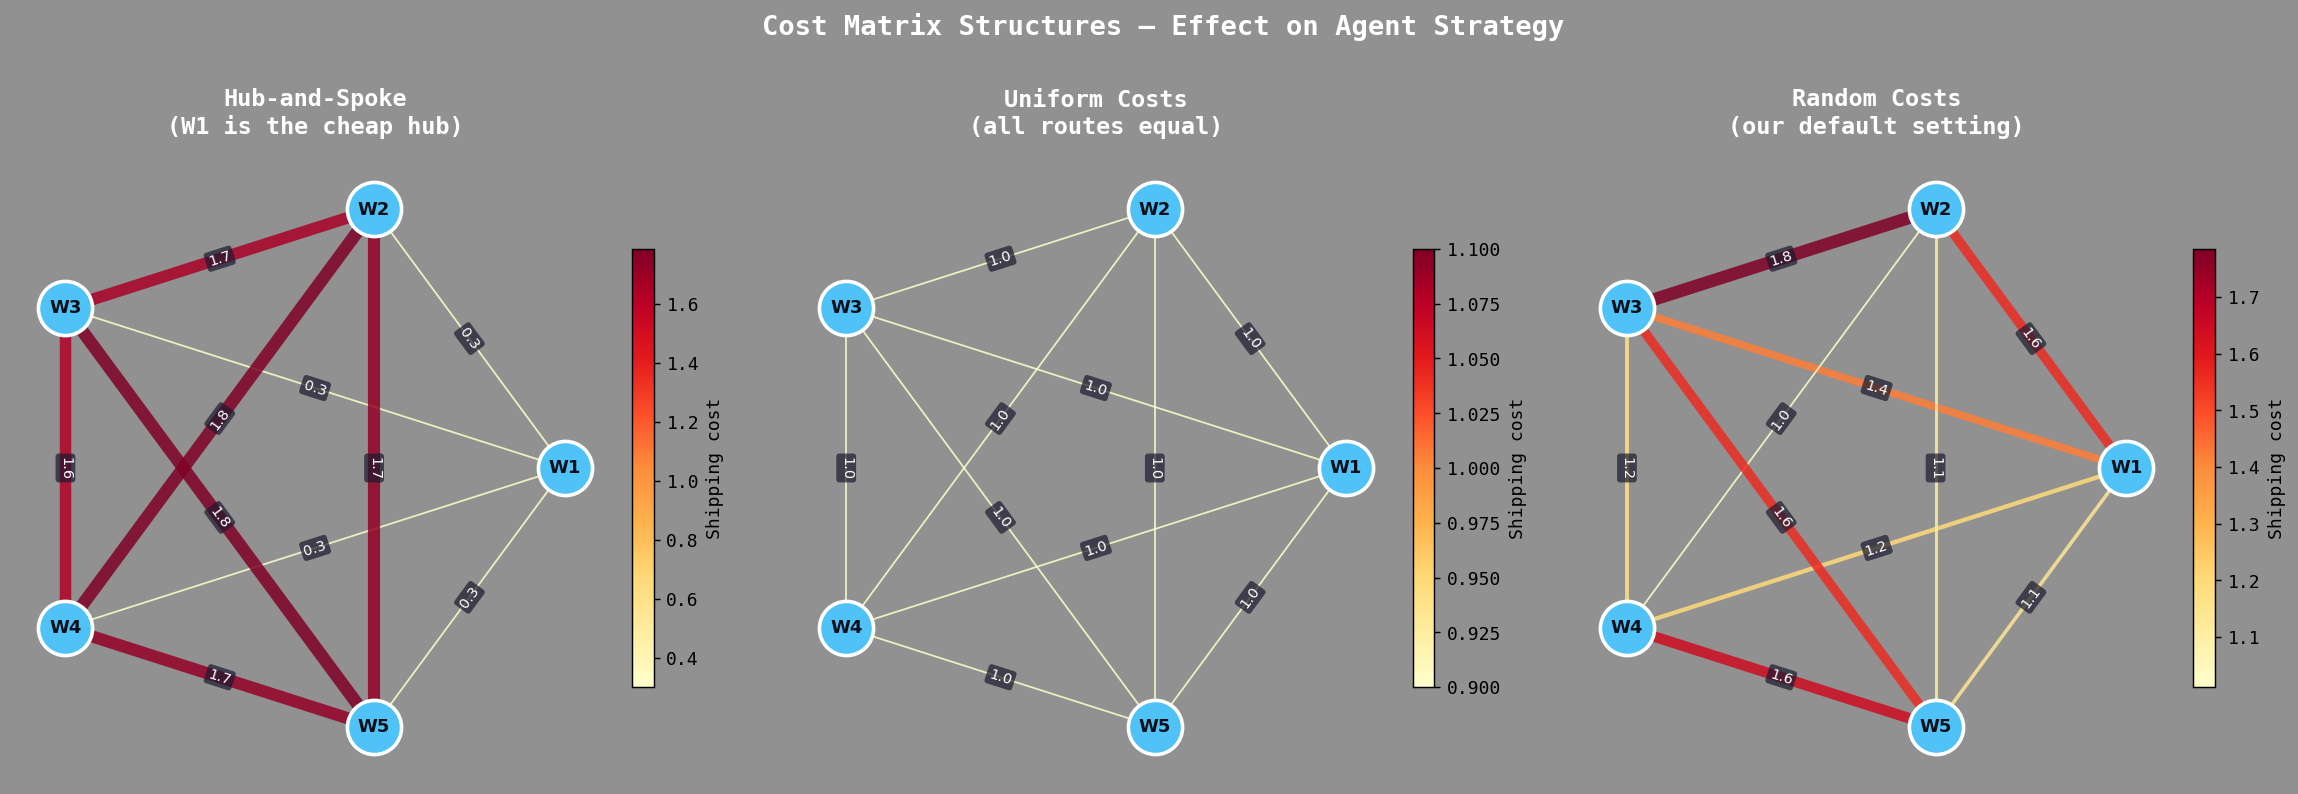

Saved → outputs/cost_matrix_comparison.png


In [ ]:
def make_hub_spoke(n, hub_cost=0.3, spoke_cost=1.9, seed=0):
    """Hub-and-spoke: warehouse 0 is cheap to reach from everywhere. Rest are expensive."""
    rng = np.random.default_rng(seed)
    C = rng.uniform(spoke_cost * 0.8, spoke_cost, size=(n, n)).astype(np.float32)
    C = (C + C.T) / 2
    # Make hub (node 0) cheap
    C[0, :] = hub_cost
    C[:, 0] = hub_cost
    np.fill_diagonal(C, 0.0)
    return C

def make_uniform(n, cost=1.0):
    """All routes cost the same — agent must rely purely on demand signal."""
    C = np.full((n, n), cost, dtype=np.float32)
    np.fill_diagonal(C, 0.0)
    return C


n_compare = 5
lbs = WAREHOUSE_NAMES[:n_compare]

C_hub     = make_hub_spoke(n_compare)
C_uniform = make_uniform(n_compare)
C_random  = (lambda rng: (lambda c: (np.fill_diagonal(c, 0) or c))(
                (lambda c: (c + c.T) / 2)(rng.uniform(0.5, 2.0, (n_compare, n_compare)).astype(np.float32))
             ))(np.random.default_rng(SEED))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#919191")

draw_warehouse_network(C_hub,     lbs, title='Hub-and-Spoke\n(W1 is the cheap hub)',  ax=axes[0])
draw_warehouse_network(C_uniform, lbs, title='Uniform Costs\n(all routes equal)',      ax=axes[1])
draw_warehouse_network(C_random,  lbs, title='Random Costs\n(our default setting)',    ax=axes[2])

fig.suptitle('Cost Matrix Structures — Effect on Agent Strategy', 
             fontsize=15, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/cost_matrix_comparison.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved → outputs/cost_matrix_comparison.png')

---
## 4b — Hub-and-Spoke with External Supplier

Three warehouses (W1 = hub, W2/W3 = spokes) plus an external supplier node.
The supplier replenishes W1 at high cost; W1 distributes cheaply to the spokes.
Matches the setup described in the report.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# --- Node positions ---
pos = {
    'Supplier': (0.5, 0.95),
    'W1\n(Hub)': (0.5, 0.55),
    'W2':       (0.15, 0.12),
    'W3':       (0.85, 0.12),
}

# --- Node styles ---
node_styles = {
    'Supplier':  {'color': '#d32f2f', 'size': 2800, 'marker': 's'},
    'W1\n(Hub)': {'color': '#1565c0', 'size': 3200, 'marker': 'o'},
    'W2':        {'color': '#2e7d32', 'size': 2200, 'marker': 'o'},
    'W3':        {'color': '#2e7d32', 'size': 2200, 'marker': 'o'},
}

# --- Draw nodes ---
for node, style in node_styles.items():
    x, y = pos[node]
    ax.scatter(x, y, s=style['size'], c=style['color'], marker=style['marker'],
               edgecolors='black', linewidths=1.5, zorder=5)
    ax.text(x, y, node, ha='center', va='center', fontsize=11, fontweight='bold',
            color='white', zorder=6)

# --- Arrow drawing helper ---
def draw_arrow(ax, src, dst, label, color, lw=3, offset=0.04, fontsize=9):
    x0, y0 = pos[src]
    x1, y1 = pos[dst]
    dx, dy = x1 - x0, y1 - y0
    norm = np.sqrt(dx**2 + dy**2)
    perp_x, perp_y = -dy / norm * offset, dx / norm * offset

    ax.annotate(
        '', xy=(x1 + perp_x, y1 + perp_y), xytext=(x0 + perp_x, y0 + perp_y),
        arrowprops=dict(
            arrowstyle='->', lw=lw, color=color, mutation_scale=25,
            shrinkA=30, shrinkB=30,
            connectionstyle='arc3,rad=0.08',
        ), zorder=3,
    )
    mx = (x0 + x1) / 2 + perp_x * 3
    my = (y0 + y1) / 2 + perp_y * 3
    ax.text(mx, my, label, ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, alpha=0.9),
            zorder=7)

# --- Main arrows ---
draw_arrow(ax, 'Supplier', 'W1\n(Hub)', 'Import\n1.0/unit', '#d32f2f', lw=4)
draw_arrow(ax, 'W1\n(Hub)', 'W2', 'Transfer\n0.5/unit', '#1565c0', lw=3.5)
draw_arrow(ax, 'W1\n(Hub)', 'W3', 'Transfer\n0.5/unit', '#1565c0', lw=3.5)
draw_arrow(ax, 'W2', 'W3', 'Spoke-Spoke\n3.0/unit', '#c62828', lw=1.5, offset=0.02)
draw_arrow(ax, 'W2', 'W1\n(Hub)', 'Reverse\n1.5/unit', '#757575', lw=1.5, offset=-0.03)
draw_arrow(ax, 'W3', 'W1\n(Hub)', 'Reverse\n1.5/unit', '#757575', lw=1.5, offset=-0.03)

# --- Direct spoke imports (expensive, dashed) ---
ax.annotate(
    '', xy=(pos['W2'][0] + 0.02, pos['W2'][1] + 0.02),
    xytext=(pos['Supplier'][0] - 0.15, pos['Supplier'][1] - 0.02),
    arrowprops=dict(
        arrowstyle='->', lw=1.5, color='#d32f2f', alpha=0.35,
        linestyle='dashed', mutation_scale=20, shrinkA=25, shrinkB=25,
        connectionstyle='arc3,rad=0.15',
    ), zorder=2,
)
ax.text(0.18, 0.58, 'Direct import\n5.0/unit', ha='center', fontsize=8,
        color='#d32f2f', alpha=0.6, style='italic',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8))

ax.annotate(
    '', xy=(pos['W3'][0] - 0.02, pos['W3'][1] + 0.02),
    xytext=(pos['Supplier'][0] + 0.15, pos['Supplier'][1] - 0.02),
    arrowprops=dict(
        arrowstyle='->', lw=1.5, color='#d32f2f', alpha=0.35,
        linestyle='dashed', mutation_scale=20, shrinkA=25, shrinkB=25,
        connectionstyle='arc3,rad=-0.15',
    ), zorder=2,
)
ax.text(0.82, 0.58, 'Direct import\n5.0/unit', ha='center', fontsize=8,
        color='#d32f2f', alpha=0.6, style='italic',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8))

# --- Capacity annotations ---
cap_style = dict(fontsize=9, color='#333333', alpha=0.8, ha='center')
ax.text(pos['W1\n(Hub)'][0], pos['W1\n(Hub)'][1] - 0.08, 'Cap: 30', **cap_style)
ax.text(pos['W2'][0], pos['W2'][1] - 0.07, 'Cap: 15', **cap_style)
ax.text(pos['W3'][0], pos['W3'][1] - 0.07, 'Cap: 15', **cap_style)

# --- Key insight box ---
ax.text(0.5, 0.005,
        'Optimal path: Supplier $\\rightarrow$ W1 $\\rightarrow$ Spokes = 1.0 + 0.5 = 1.5/unit\n'
        'Direct spoke import = 5.0/unit  (3.3$\\times$ more expensive)',
        ha='center', va='bottom', fontsize=10, color='#1b5e20',
        bbox=dict(boxstyle='round,pad=0.6', fc='#e8f5e9', ec='#2e7d32', alpha=0.95),
        zorder=8)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.07, 1.08)
ax.axis('off')
ax.set_title('Hub-and-Spoke Network with External Supplier',
             fontsize=15, fontweight='bold', color='black', pad=15)

plt.tight_layout()
plt.savefig('../outputs/hub_spoke_supplier_diagram.png', bbox_inches='tight',
            facecolor='white', dpi=150)
plt.show()
print('Saved -> outputs/hub_spoke_supplier_diagram.png')

---
## 5 — Plug Your Matrix Back into the Environment

Pass `cost_matrix` in the config to override random generation.

In [ ]:
import sys, yaml
sys.path.append('..')
from env.warehouse_env import WarehouseEnv

with open('../configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

# Inject our manual cost matrix into the env config
cfg['env']['n_warehouses'] = N
cfg['env']['cost_matrix'] = C.tolist()   # YAML needs a plain list

env = WarehouseEnv(cfg['env'], seed=SEED)
state = env.reset()

print('✓ Environment created with custom cost matrix')
print(f'  n_warehouses  : {env.n}')
print(f'  inventory     : {state["inventory"].round(1)}')
print(f'  demand        : {state["demand"].round(1)}')
print(f'  cost_matrix OK: {np.allclose(env.cost_matrix, C)}')

# One random step to confirm step() works
action = env.sample_action()
next_state, reward, done, info = env.step(action)
print(f'\nOne random step:')
print(f'  reward           : {reward:.3f}')
print(f'  transport_cost   : {info["transport_cost"]:.3f}')
print(f'  unmet_demand     : {info["unmet_demand"]:.3f}')
print(f'  demand_satisf.   : {info["demand_satisfaction"]:.3f}')

✓ Environment created with custom cost matrix
  n_warehouses  : 4
  inventory     : [77.4 43.9 85.9 69.7]
  demand        : [ 6.  9. 11.  9.]
  cost_matrix OK: True

One random step:
  reward           : -145.461
  transport_cost   : 145.461
  unmet_demand     : 0.000
  demand_satisf.   : 1.029
